# Demonstrate subpixel superresolution

In [1]:
# @title Initialization
import numpy as np
from scipy import ndimage
from PIL import Image, ImageDraw, ImageFont

from bokeh.io import output_notebook, show
from bokeh.plotting import figure, gridplot, column, row
from bokeh.palettes import Greys256, Inferno256
from bokeh.models import LinearColorMapper
from bokeh.models import HoverTool, CrosshairTool
import ipywidgets as widgets
from IPython.display import display, Markdown

output_notebook()


Loading BokehJS ...

In [2]:
# @title Bokeh Image Display Helper
def bokeh_image(img, title="", width=380, height=380, palette=Greys256):
    p = figure(
        title=title,
        width=width,
        height=height,
        tools="pan,wheel_zoom,box_zoom,reset,save,crosshair",
        x_range=(0, img.shape[1]),
        y_range=(0, img.shape[0])
    )
    p.image(
        image=[np.flipud(img)],
        x=0, y=0,
        dw=img.shape[1],
        dh=img.shape[0],
        palette=palette
    )
    hover = HoverTool(
        tooltips=[
            ("(x, y)", "($x{int}, $y{int})"),
            ("Pixel Value", "@image"),
        ],
        mode='mouse'
    )

    crosshair = CrosshairTool(dimensions="both")

    p.add_tools(hover, crosshair)
    p.axis.visible = False
    p.grid.visible = False
    return p

In [53]:
# @title Create High-Resolution Test Image (400×400)
def create_test_image(size=400):
    img = Image.new('L', (size, size), 240)
    draw = ImageDraw.Draw(img)

    try:
        font_large = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 36)
        font_small = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 18)
    except:
        font_large = ImageFont.load_default()
        font_small = ImageFont.load_default()

    draw.text((30, 30), "SUBPIXEL", fill=30, font=font_large)
    draw.text((30, 75), "SUPER-RES", fill=30, font=font_large)

    for i in range(0, size, 8):
        draw.line([(i, 140), (i + 4, size-20)], fill=50, width=1)
    for i in range(0, size, 12):
        draw.ellipse([i, 160+i/10, i+6, 166+i/10], fill=20)

    for y in range(200, 350, 3):
        for x in range(50, 350, 3):
            if (x + y) % 6 < 3:
                draw.point((x, y), fill=0)

    draw.text((30, 360), "DEMO 2026", fill=10, font=font_small)

    hr = np.array(img, dtype=np.float32) / 255.0
    return hr

hr = create_test_image(400)
p1 = bokeh_image(hr, "Original HR", width=400, height=400)
show(p1)
print(f"HR image created: {hr.shape}")

HR image created: (400, 400)


In [ ]:
# @title Simulate 4 Low-Resolution Images (Subpixel Shifts)
def simulate_lr(hr, shift_x, shift_y, factor=2):
    shifted = ndimage.shift(hr, (shift_y, shift_x), order=3, mode='nearest')
    h, w = shifted.shape
    lr = shifted.reshape(h//factor, factor, w//factor, factor).mean(axis=(1, 3))
    return lr

factor = 2
shifts = [(0.0, 0.0), (0.0, 0.5), (0.5, 0.0), (0.5, 0.5)]

lr_images = [simulate_lr(hr, sx, sy, factor) for sx, sy in shifts]

# Display all 4 LR images in a grid
plots = []
for lr, (sx, sy) in zip(lr_images, shifts):
    plots.append(bokeh_image(lr, f"LR Shift ({sx}, {sy})", width=280, height=280))

grid = gridplot([plots[:2], plots[2:]], toolbar_location="above")
show(grid)

In [ ]:
# @title Simulate 4 Low-Resolution Images (Subpixel Shifts)
def simulate_lr(hr, shift_x, shift_y, factor=2):
    shifted = ndimage.shift(hr, (shift_y, shift_x), order=3, mode='nearest')
    h, w = shifted.shape
    lr = shifted.reshape(h//factor, factor, w//factor, factor).mean(axis=(1, 3))
    return lr

factor = 2
nr_of_shifts = 100

shifts = [np.random.uniform(0, 1, size=2) for _ in range(nr_of_shifts)]

lr_images = [simulate_lr(hr, sx, sy, factor) for sx, sy in shifts]

# Display all 4 LR images in a grid
plots = []
for lr, (sx, sy) in zip(lr_images, shifts):
    plots.append(bokeh_image(lr, f"LR Shift ({sx}, {sy})", width=280, height=280))

grid = gridplot(plots, ncols = 4, toolbar_location="above")
show(grid)

In [77]:
def reconstruct_hr(lr_images, shifts, factor=2):
    h_lr, w_lr = lr_images[0].shape
    h_hr, w_hr = h_lr * factor, w_lr * factor

    hr_accum = np.zeros((h_hr, w_hr))
    weight = np.zeros((h_hr, w_hr))

    for lr, (sx, sy) in zip(lr_images, shifts):
        # Step 1: Upsample (nearest or bilinear)
        upsampled = np.repeat(np.repeat(lr, factor, axis=0), factor, axis=1)

        # Step 2: Undo shift (note the minus!)
        aligned = ndimage.shift(upsampled, (-sy, -sx), order=3)

        # Step 3: Accumulate
        hr_accum += aligned
        weight += 1

    return hr_accum / weight

def back_project(hr_est, lr_images, shifts, factor, iterations=10):
    for _ in range(iterations):
        correction = np.zeros_like(hr_est)

        for lr, (sx, sy) in zip(lr_images, shifts):
            # simulate LR from current estimate
            simulated = simulate_lr(hr_est, sx, sy, factor)

            error = lr - simulated

            # project error back to HR
            up = np.repeat(np.repeat(error, factor, axis=0), factor, axis=1)
            aligned = ndimage.shift(up, (-sy, -sx), order=3)

            correction += aligned

        hr_est += correction / len(lr_images)

    return hr_est


In [78]:

# Initial estimate
hr_est = reconstruct_hr(lr_images, shifts, factor)

# Refine
hr_final = back_project(hr_est, lr_images, shifts, factor, iterations=15)


In [79]:
p_reconstr = bokeh_image(hr_final, "Reconstructed HR", width=400, height=400)
plr1crop = bokeh_image(lr_images[0], "Original LR (Crop)", width=400, height=400)
show(row(plr1crop, p_reconstr))

In [63]:
lr_images[0].shape, hr_final.shape

((200, 200), (400, 400))

In [27]:
# @title Naive Bicubic Upsampling (Baseline)
lr0 = lr_images[0]
naive_hr = ndimage.zoom(lr0, factor, order=3)

# Create three Bokeh plots
p1 = bokeh_image(hr, "Original HR", width=320, height=320)
p2 = bokeh_image(naive_hr, "Naive Bicubic Upsample", width=320, height=320)

# Error map with Inferno palette
error = np.abs(hr - naive_hr)
p3 = bokeh_image(error, "Absolute Error", width=320, height=320, palette=Inferno256)

show(row(p1, p2, p3))

In [6]:
# @title Subpixel Super-Resolution via Interleaving
def subpixel_superresolve(lr_images, shifts, factor=2):
    h, w = lr_images[0].shape
    hr_h, hr_w = h * factor, w * factor
    sr = np.zeros((hr_h, hr_w), dtype=np.float32)
    count = np.zeros((hr_h, hr_w), dtype=np.float32)

    for lr, (sx, sy) in zip(lr_images, shifts):
        phase_y = int(round(sy * factor)) % factor
        phase_x = int(round(sx * factor)) % factor
        sr[phase_y::factor, phase_x::factor] = lr
        count[phase_y::factor, phase_x::factor] += 1

    sr = np.divide(sr, count, out=np.zeros_like(sr), where=count > 0)
    return sr

sr = subpixel_superresolve(lr_images, shifts, factor)

# Side-by-side comparison with Bokeh
p_orig = bokeh_image(hr[100:200, 100:200], "Original HR", width=320, height=320)
p_naive = bokeh_image(naive_hr[100:200, 100:200], "Naive Bicubic", width=320, height=320)
p_sr = bokeh_image(sr[100:200, 100:200], "Subpixel SR (Ours)", width=320, height=320)
error = np.abs(hr - naive_hr)


show(row(p_orig, p_naive, p_sr))

# PSNR
mse = np.mean((hr - sr)**2)
psnr = 20 * np.log10(1.0 / np.sqrt(mse))
print(f"PSNR of Subpixel SR: {psnr:.2f} dB  (Higher = Better)")

PSNR of Subpixel SR: 13.34 dB  (Higher = Better)


In [28]:
# @title Final Demo – Adjustable Parameters (Recommended for Class)

# ====================== PARAMETERS ======================
num_shifts   = 8          # Number of LR images (2–9)
noise_level  = 0.0        # Add noise: 0.0 = none, 0.05–0.15 = visible noise
factor       = 2          # Downsampling factor (2, 3, or 4)
# ========================================================

# Generate shifts
if num_shifts <= 4:
    shifts = [(0.0, 0.0), (0.0, 0.5), (0.5, 0.0), (0.5, 0.5)][:num_shifts]
else:
    shifts = [(np.random.rand(), np.random.rand()) for _ in range(num_shifts)]

# Simulate LR images with current parameters
lr_list = [simulate_lr(hr, sx, sy, factor) for sx, sy in shifts]

# Add noise if requested
if noise_level > 0:
    lr_list = [np.clip(lr + noise_level * np.random.randn(*lr.shape), 0, 1) for lr in lr_list]

# Reconstruct using current parameters
sr = subpixel_superresolve(lr_list, shifts, factor)
naive = ndimage.zoom(lr_list[0], factor, order=3)

# Create the three plots
p1 = bokeh_image(hr[80:180, 80:180], "Original High-Resolution", width=320, height=320)
p2 = bokeh_image(naive[80:180, 80:180], f"Naive Bicubic (factor={factor})", width=320, height=320)
p3 = bokeh_image(sr[80:180, 80:180], f"Subpixel SR ({num_shifts} frames)", width=320, height=320)

# Display side by side
show(row(p1, p2, p3))

print(f"\nParameters used → num_shifts={num_shifts}, noise_level={noise_level}, factor={factor}")


Parameters used → num_shifts=8, noise_level=0.0, factor=2


In [31]:
# @title Interactive Demo – Should Work Now
import ipywidgets as widgets
from IPython.display import display, clear_output
from bokeh.io import output_notebook, show
from bokeh.layouts import row

# Controls (stay visible)
num_shifts = widgets.IntSlider(value=4, min=2, max=9, step=1, description="Number of LR images")
noise_level = widgets.FloatSlider(value=0.0, min=0.0, max=0.15, step=0.01, description="Noise level")
factor = widgets.IntSlider(value=2, min=2, max=4, step=1, description="Downsample factor")
button = widgets.Button(description="Update Plot", button_style='success')

def on_button_clicked(b):
    clear_output(wait=True)          # clears old plots only

    n = num_shifts.value
    noise = noise_level.value
    f = factor.value

    # Generate shifts
    if n <= 4:
        shifts = [(0.0, 0.0), (0.0, 0.5), (0.5, 0.0), (0.5, 0.5)][:n]
    else:
        shifts = [(np.random.rand(), np.random.rand()) for _ in range(n)]

    lr_list = [simulate_lr(hr, sx, sy, f) for sx, sy in shifts]

    if noise > 0:
        lr_list = [np.clip(lr + noise * np.random.randn(*lr.shape), 0, 1) for lr in lr_list]

    sr = subpixel_superresolve(lr_list, shifts, f)
    naive = ndimage.zoom(lr_list[0], f, order=3)

    # Create and show plots directly
    p1 = bokeh_image(hr[80:180, 80:180], "Original HR", width=300, height=300)
    p2 = bokeh_image(naive[80:180, 80:180], "Naive Upsample", width=300, height=300)
    p3 = bokeh_image(sr[80:180, 80:180], f"Subpixel SR ({n} frames)", width=300, height=300)

    show(row(p1, p2, p3))

button.on_click(on_button_clicked)

# Display controls
display(num_shifts, noise_level, factor, button)

## Read video (mp4)

In [11]:
import cv2
import numpy as np
from tqdm import tqdm   # optional, for progress bar

def read_video_to_array(video_path, max_frames=None, grayscale=True):
    """
    Read an MP4 video into a NumPy array.

    Returns:
        frames: np.ndarray with shape (num_frames, H, W, 3) or (num_frames, H, W) if grayscale=True
    """
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")

    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    if max_frames:
        total_frames = min(total_frames, max_frames)

    print(f"Reading {total_frames} frames from video...")

    for i in tqdm(range(total_frames), desc="Reading frames"):
        ret, frame = cap.read()
        if not ret:
            break

        if grayscale:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        else:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # Convert to RGB

        frames.append(frame)

    cap.release()
    return np.array(frames)

In [14]:
# Read first 100 frames in BW
frames = read_video_to_array("license_trim_low.mp4", max_frames=100)

print(f"Shape: {frames.shape}")        # (30, height, width, 3)
print(f"Dtype: {frames.dtype}")        # uint8

Reading 29 frames from video...


Reading frames: 100%|██████████| 29/29 [00:00<00:00, 795.40it/s]

Shape: (29, 358, 638)
Dtype: uint8


In [92]:
f1=bokeh_image(frames[0,:,:], width=640, height=320)
show(f1)

f1=bokeh_image(frames[10,:,:], width=640, height=320)
show(f1)

In [123]:
def estimate_shifts(frames):
    ref = frames[0].astype(np.float32)
    shifts = [(0.0, 0.0)]  # reference frame

    for i in range(1, len(frames)):
        frame = frames[i].astype(np.float32)

        shift, _ = cv2.phaseCorrelate(ref, frame)
        # shift = (dx, dy)

        shifts.append(shift)

    return shifts

# def estimate_shifts(frames):
#     ref = apply_hann(frames[0].astype(np.float32))
#     shifts = [(0.0, 0.0)]

#     for i in range(1, len(frames)):
#         frame = apply_hann(frames[i].astype(np.float32))
#         shift, _ = cv2.phaseCorrelate(ref, frame)
#         shifts.append(shift)

#     return shifts

def align_frames(frames, shifts):
    aligned = []

    for frame, (dx, dy) in zip(frames, shifts):
        shifted = ndimage.shift(frame, (-dy, -dx), order=3)
        aligned.append(shifted)

    return np.array(aligned)

def apply_hann(img):
    h, w = img.shape
    return img * np.outer(np.hanning(h), np.hanning(w))

def reconstruct_from_video(frames, shifts, factor=2):
    h_lr, w_lr = frames[0].shape
    h_hr, w_hr = h_lr * factor, w_lr * factor

    hr_accum = np.zeros((h_hr, w_hr))
    weight = np.zeros((h_hr, w_hr))

    for frame, (dx, dy) in zip(frames, shifts):
        # Upsample
        up = np.repeat(np.repeat(frame, factor, axis=0), factor, axis=1)

        # Align in HR space
        aligned = ndimage.shift(up, (-dy * factor, -dx * factor), order=3)

        hr_accum += aligned
        weight += 1

    return hr_accum / weight

In [124]:
h, w = frames[0].shape

y1, y2 = h - 150, h - 40
x1, x2 = 140, 260

roi_frames = frames[:, y1:y2, x1:x2]

print("ROI shape:", roi_frames.shape)
shifts = estimate_shifts(roi_frames[:5])
hr = reconstruct_from_video(roi_frames, shifts, factor=2)

ROI shape: (29, 110, 120)


In [125]:
show(bokeh_image(hr, width=640, height=320))

ROI shape: (3, 110, 120)
Estimated shifts: [(0.0, 0.0), (-0.5401375061513809, 1.0264569835890303), (0.41757218784344563, 1.099346942728204)] ...


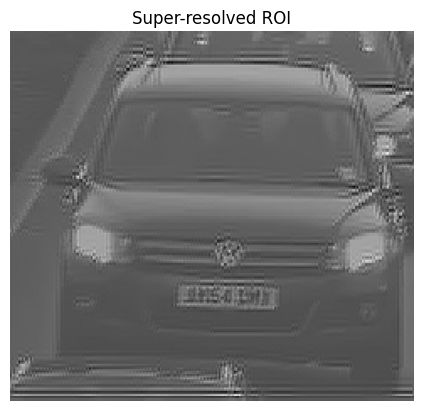

In [119]:
import cv2
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt

# -----------------------------
# 1. ROI extraction
# -----------------------------
def extract_roi(frames, x1, x2, y1, y2):
    h, w = frames[0].shape

    # Clamp coordinates to valid range
    x1, x2 = int(max(0, x1)), int(min(w, x2))
    y1, y2 = int(max(0, y1)), int(min(h, y2))

    roi = frames[:, y1:y2, x1:x2]

    if roi.shape[1] == 0 or roi.shape[2] == 0:
        raise ValueError("ROI is empty. Check coordinates!")

    return roi


# -----------------------------
# 2. Feature-based shift estimation
# -----------------------------
def estimate_shift_features(img1, img2):
    orb = cv2.ORB_create(nfeatures=500)

    kp1, des1 = orb.detectAndCompute(img1, None)
    kp2, des2 = orb.detectAndCompute(img2, None)

    if des1 is None or des2 is None:
        return (0.0, 0.0)

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)

    if len(matches) < 5:
        return (0.0, 0.0)

    matches = sorted(matches, key=lambda x: x.distance)

    pts1 = np.float32([kp1[m.queryIdx].pt for m in matches])
    pts2 = np.float32([kp2[m.trainIdx].pt for m in matches])

    # RANSAC affine (robust)
    M, _ = cv2.estimateAffinePartial2D(pts1, pts2, method=cv2.RANSAC)

    if M is None:
        return (0.0, 0.0)

    dx = M[0, 2]
    dy = M[1, 2]

    return (dx, dy)


def estimate_shifts(frames):
    shifts = [(0.0, 0.0)]

    for i in range(1, len(frames)):
        dx, dy = estimate_shift_features(frames[i-1], frames[i])

        cum_dx = shifts[-1][0] + dx
        cum_dy = shifts[-1][1] + dy

        shifts.append((cum_dx, cum_dy))

    return shifts


# -----------------------------
# 3. Reconstruction (shift-and-add)
# -----------------------------
def reconstruct_from_video(frames, shifts, factor=2):
    h_lr, w_lr = frames[0].shape
    h_hr, w_hr = h_lr * factor, w_lr * factor

    hr_accum = np.zeros((h_hr, w_hr), dtype=np.float32)
    weight = np.zeros((h_hr, w_hr), dtype=np.float32)

    for frame, (dx, dy) in zip(frames, shifts):
        # Upsample
        up = np.repeat(np.repeat(frame, factor, axis=0), factor, axis=1)

        # Align (note: dy, dx order)
        aligned = ndimage.shift(up, (-dy * factor, -dx * factor), order=3)

        hr_accum += aligned
        weight += 1

    return hr_accum / (weight + 1e-8)


# -----------------------------
# 4. Optional refinement (back-projection)
# -----------------------------
def simulate_lr(hr, shift_x, shift_y, factor=2):
    shifted = ndimage.shift(hr, (shift_y, shift_x), order=3, mode='nearest')
    h, w = shifted.shape
    lr = shifted.reshape(h//factor, factor, w//factor, factor).mean(axis=(1, 3))
    return lr


def back_project(hr_est, frames, shifts, factor=2, iterations=10):
    for _ in range(iterations):
        correction = np.zeros_like(hr_est)

        for frame, (dx, dy) in zip(frames, shifts):
            simulated = simulate_lr(hr_est, dx, dy, factor)
            error = frame - simulated

            up = np.repeat(np.repeat(error, factor, axis=0), factor, axis=1)
            aligned = ndimage.shift(up, (-dy * factor, -dx * factor), order=3)

            correction += aligned

        hr_est += correction / len(frames)

    return hr_est


# -----------------------------
# 5. Full pipeline runner
# -----------------------------
def super_resolve_video(frames, x1, x2, y1, y2, factor=2, refine=True):
    # ROI
    roi_frames = extract_roi(frames, x1, x2, y1, y2)
    print("ROI shape:", roi_frames.shape)

    # Motion estimation
    shifts = estimate_shifts(roi_frames)
    print("Estimated shifts:", shifts[:5], "...")

    # Reconstruction
    hr = reconstruct_from_video(roi_frames, shifts, factor=factor)

    # Optional refinement
    if refine:
        hr = back_project(hr, roi_frames, shifts, factor=factor, iterations=10)

    return hr


# -----------------------------
# 6. Example usage
# -----------------------------
# Adjust these to your case
h, w = frames[0].shape

y1, y2 = h - 150, h - 40
x1, x2 = 140, 260

hr = super_resolve_video(frames[:3], x1, x2, y1, y2, factor=2)

# Display result
plt.imshow(hr, cmap='gray')
plt.title("Super-resolved ROI")
plt.axis('off')
plt.show()

In [32]:
# @title Interactive frame search
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np
import cv2

def show_tracked_frame(frame_idx):
    clear_output(wait=True)

    fig, ax = plt.subplots(figsize=(10, 8))

    # Show current frame
    img = frames[frame_idx]
    ax.imshow(img, cmap='gray')

    ax.set_title(f"Frame {frame_idx} / {len(frames)-1}")
    ax.axis('off')

    plt.tight_layout()
    plt.show()

# Create slider
slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(frames) - 1,
    step=1,
    description="Frame:",
    continuous_update=True,
    style={'description_width': 'initial'}
)

# Connect slider to function
widgets.interact(show_tracked_frame, frame_idx=slider)

print("✅ Move the slider to browse frames and see tracked features!")

interactive(children=(IntSlider(value=0, description='Frame:', max=28, style=SliderStyle(description_width='in…

✅ Move the slider to browse frames and see tracked features!


In [ ]:
def detect_and_track_features(frames, max_corners=100, quality=0.01, min_distance=10):
    """
    Detect good features in first frame and track them across all frames.
    Returns list of tracked points for each frame.
    """
    # Parameters for Shi-Tomasi corner detection
    feature_params = dict(
        maxCorners=max_corners,
        qualityLevel=quality,
        minDistance=min_distance,
        blockSize=7
    )

    # Parameters for Lucas-Kanade optical flow
    lk_params = dict(
        winSize=(15, 15),
        maxLevel=2,
        criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
    )

    # Detect features in first frame
    prev_gray = frames[0]
    p0 = cv2.goodFeaturesToTrack(prev_gray, mask=None, **feature_params)

    all_tracks = [p0.reshape(-1, 2)]   # Store points for frame 0

    for i in range(1, len(frames)):
        curr_gray = frames[i]

        # Track features
        p1, st, err = cv2.calcOpticalFlowPyrLK(
            prev_gray, curr_gray, p0, None, **lk_params
        )

        # Keep only good matches
        good_new = p1[st == 1]
        good_old = p0[st == 1]

        all_tracks.append(good_new)

        # Prepare for next iteration
        prev_gray = curr_gray.copy()
        p0 = good_new.reshape(-1, 1, 2)

    return all_tracks

In [ ]:
import matplotlib.pyplot as plt
def visualize_feature_tracks(frames, all_tracks, frame_idx=0):
    """Draw tracked features on a specific frame"""
    img = cv2.cvtColor(frames[frame_idx], cv2.COLOR_GRAY2BGR)

    for i in range(1, len(all_tracks)):
        if i > frame_idx:
            break
        points = all_tracks[i]
        for pt in points:
            x, y = int(pt[0]), int(pt[1])
            cv2.circle(img, (x, y), 3, (0, 255, 0), -1)

    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Tracked Features on Frame {frame_idx}")
    plt.axis('off')
    plt.show()

In [ ]:
# @title Interactive Feature Tracking Viewer (Matplotlib Version)
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import numpy as np
import cv2

def show_tracked_frame(frame_idx):
    clear_output(wait=True)

    fig, ax = plt.subplots(figsize=(10, 8))

    # Show current frame
    img = frames[frame_idx]
    ax.imshow(img, cmap='gray')

    # Overlay tracked features
    if frame_idx < len(tracks) and len(tracks[frame_idx]) > 0:
        points = tracks[frame_idx]
        ax.scatter(
            points[:, 0],
            points[:, 1],
            c='lime',
            s=40,
            marker='o',
            edgecolors='black',
            linewidths=0.5,
            label='Tracked Features'
        )

    ax.set_title(f"Frame {frame_idx} / {len(frames)-1}  |  Features: {len(tracks[frame_idx]) if frame_idx < len(tracks) else 0}")
    ax.axis('off')
    ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

# Create slider
slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(frames) - 1,
    step=1,
    description="Frame:",
    continuous_update=True,
    style={'description_width': 'initial'}
)

# Connect slider to function
widgets.interact(show_tracked_frame, frame_idx=slider)

print("✅ Move the slider to browse frames and see tracked features!")

interactive(children=(IntSlider(value=0, description='Frame:', max=99, style=SliderStyle(description_width='in…

✅ Move the slider to browse frames and see tracked features!
